# Price vs Alternative Data Dashboard

Notebook do wizualnej inspekcji zaleznosci miedzy cena akcji i alt-data na bazie `session_aligned`.

Co pokazuje:
- pojedynczy wykres `stock price + Reddit sentiment`,
- cene i wolumen,
- Google Trends i GDELT articles,
- GDELT sentiment,
- Reddit activity,
- Reddit sentiment osobno dla submissions i comments,
- normalized overlay do szybkiego porownania ksztaltu serii.


In [12]:
from notebooks_two_tickers_session_aligned import visualize_price_alt_dashboard
%matplotlib inline

import pandas as pd
import sys
import importlib

if "visualize_price_alt_dashboard" in sys.modules:
    importlib.reload(sys.modules["visualize_price_alt_dashboard"])

    sys.path.append("../notebooks_two_tickers_session_aligned")

from visualize_price_alt_dashboard import (
    load_panel,
    plot_normalized_overlay,
    plot_price_vs_reddit_sentiment,
    plot_ticker_dashboard,
    save_dashboard,
    summarize_window,
)

panel = load_panel()
panel.groupby("ticker").agg(
    date_min=("date", "min"),
    date_max=("date", "max"),
    rows=("date", "size"),
).reset_index()


,ticker,date_min,date_max,rows
0,AAPL,2023-01-03,2025-12-31,752
1,TSLA,2023-01-03,2025-12-31,752


In [13]:
ticker = "AAPL"
start = "2024-01-01"
end = "2025-12-31"
sentiment_variant = "combined"  # 'combined', 'subm', 'comm'
normalize_price = False

window = panel[(panel["ticker"] == ticker) & (panel["date"] >= start) & (panel["date"] <= end)].copy()
summarize_window(window)


,ticker,rows,date_min,date_max,future_up_share,avg_price_return_1d,avg_trends,avg_gdelt_articles,avg_reddit_posts_total
0,AAPL,502,2024-01-02,2025-12-31,0.543825,0.00086,64.672477,1.562085,53.631474


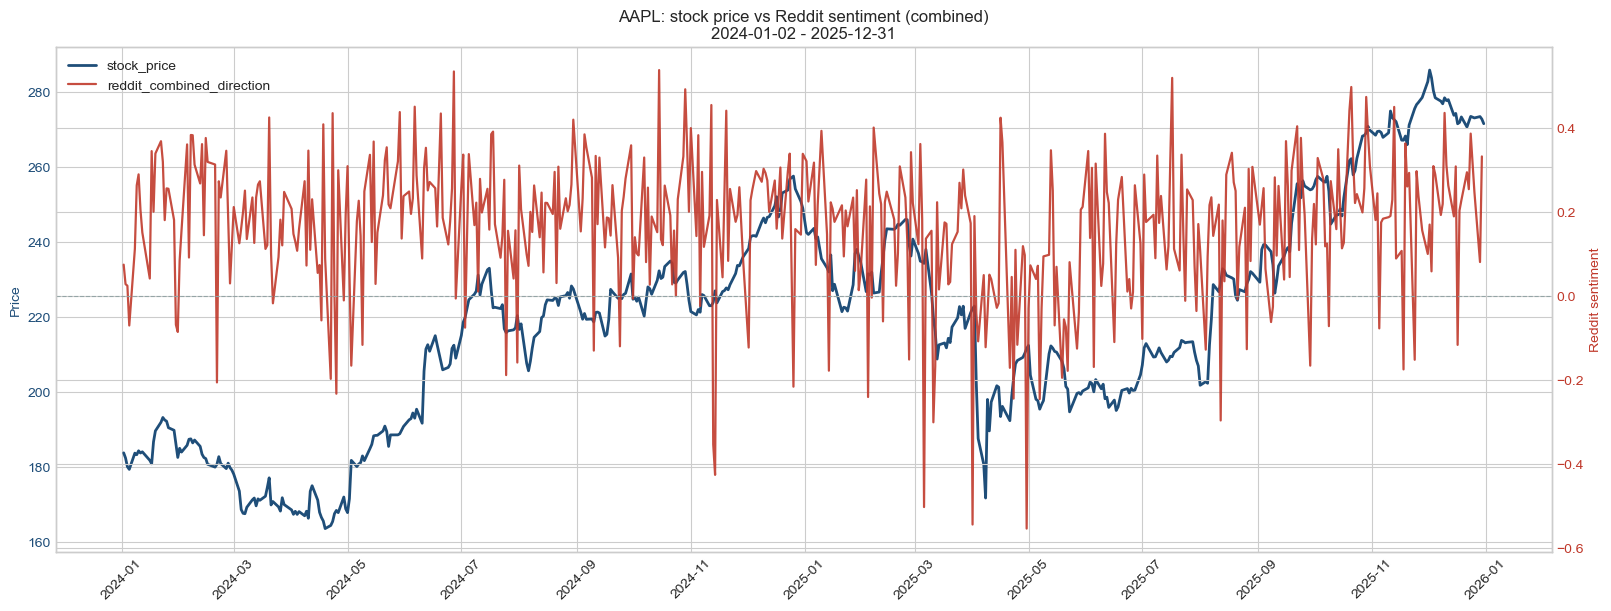

In [14]:
plot_price_vs_reddit_sentiment(
    panel,
    ticker=ticker,
    start=start,
    end=end,
    sentiment_variant=sentiment_variant,
    normalize_price=normalize_price,
);


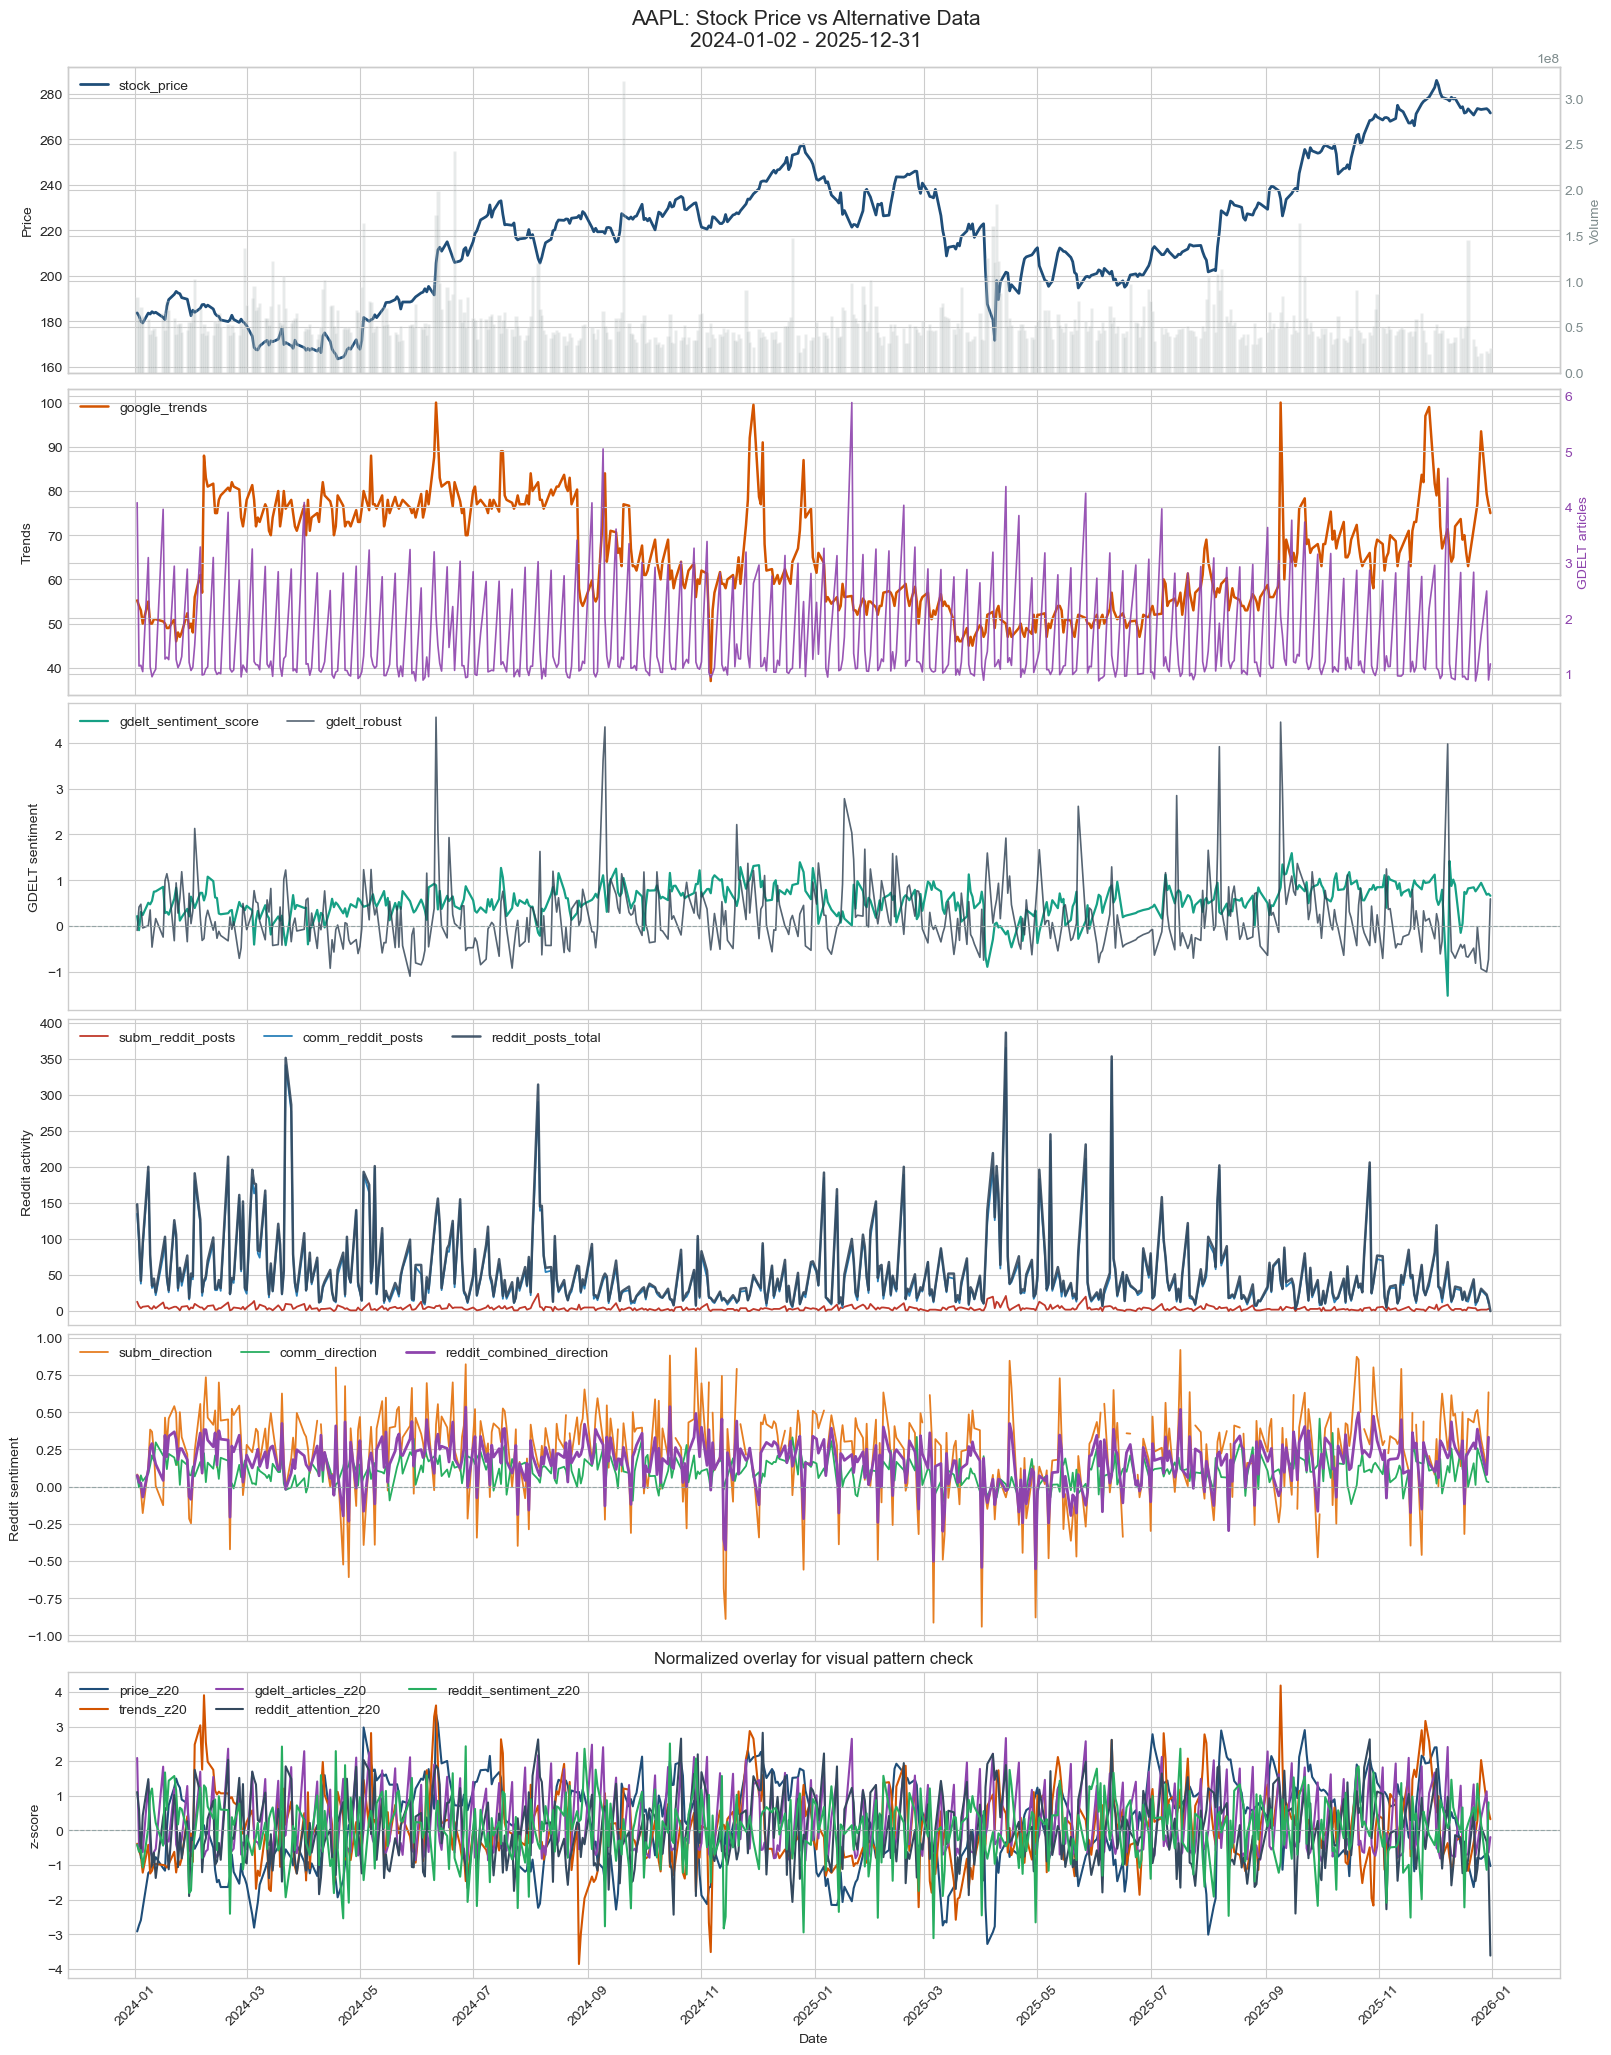

In [15]:
plot_ticker_dashboard(panel, ticker=ticker, start=start, end=end);


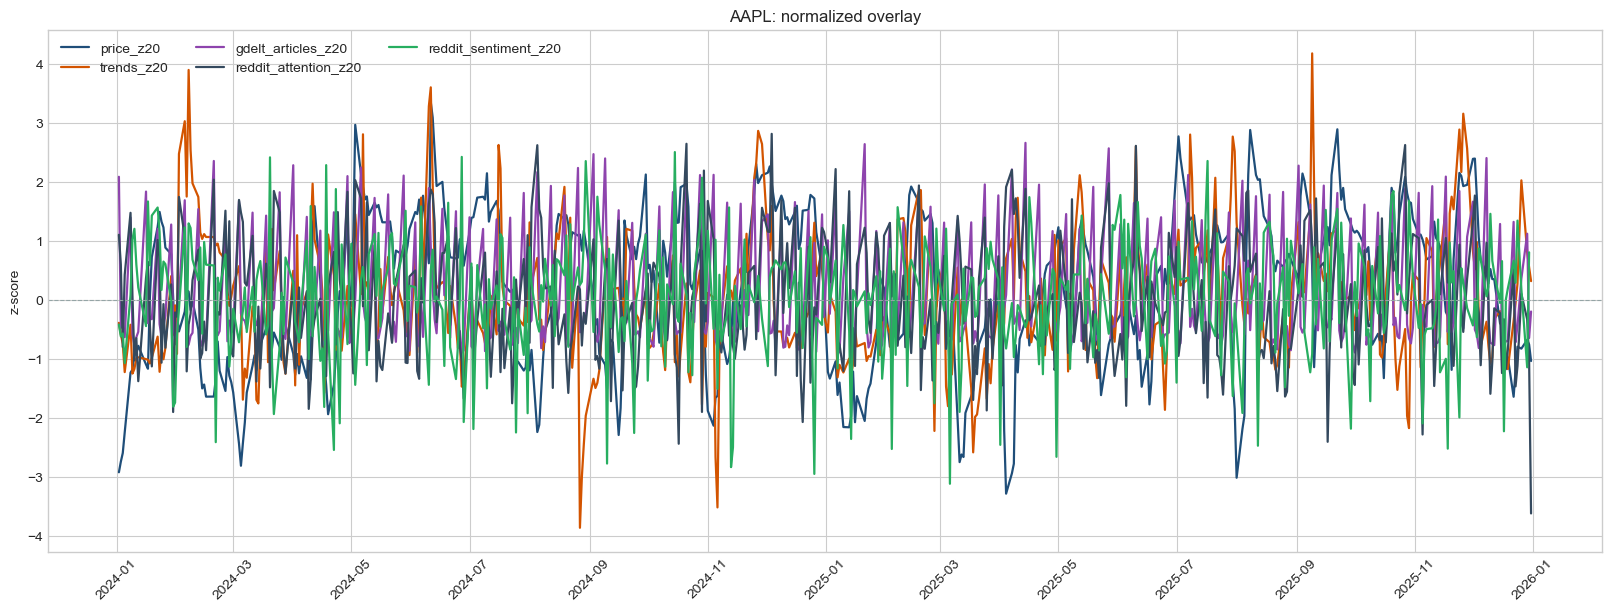

In [16]:
plot_normalized_overlay(panel, ticker=ticker, start=start, end=end);


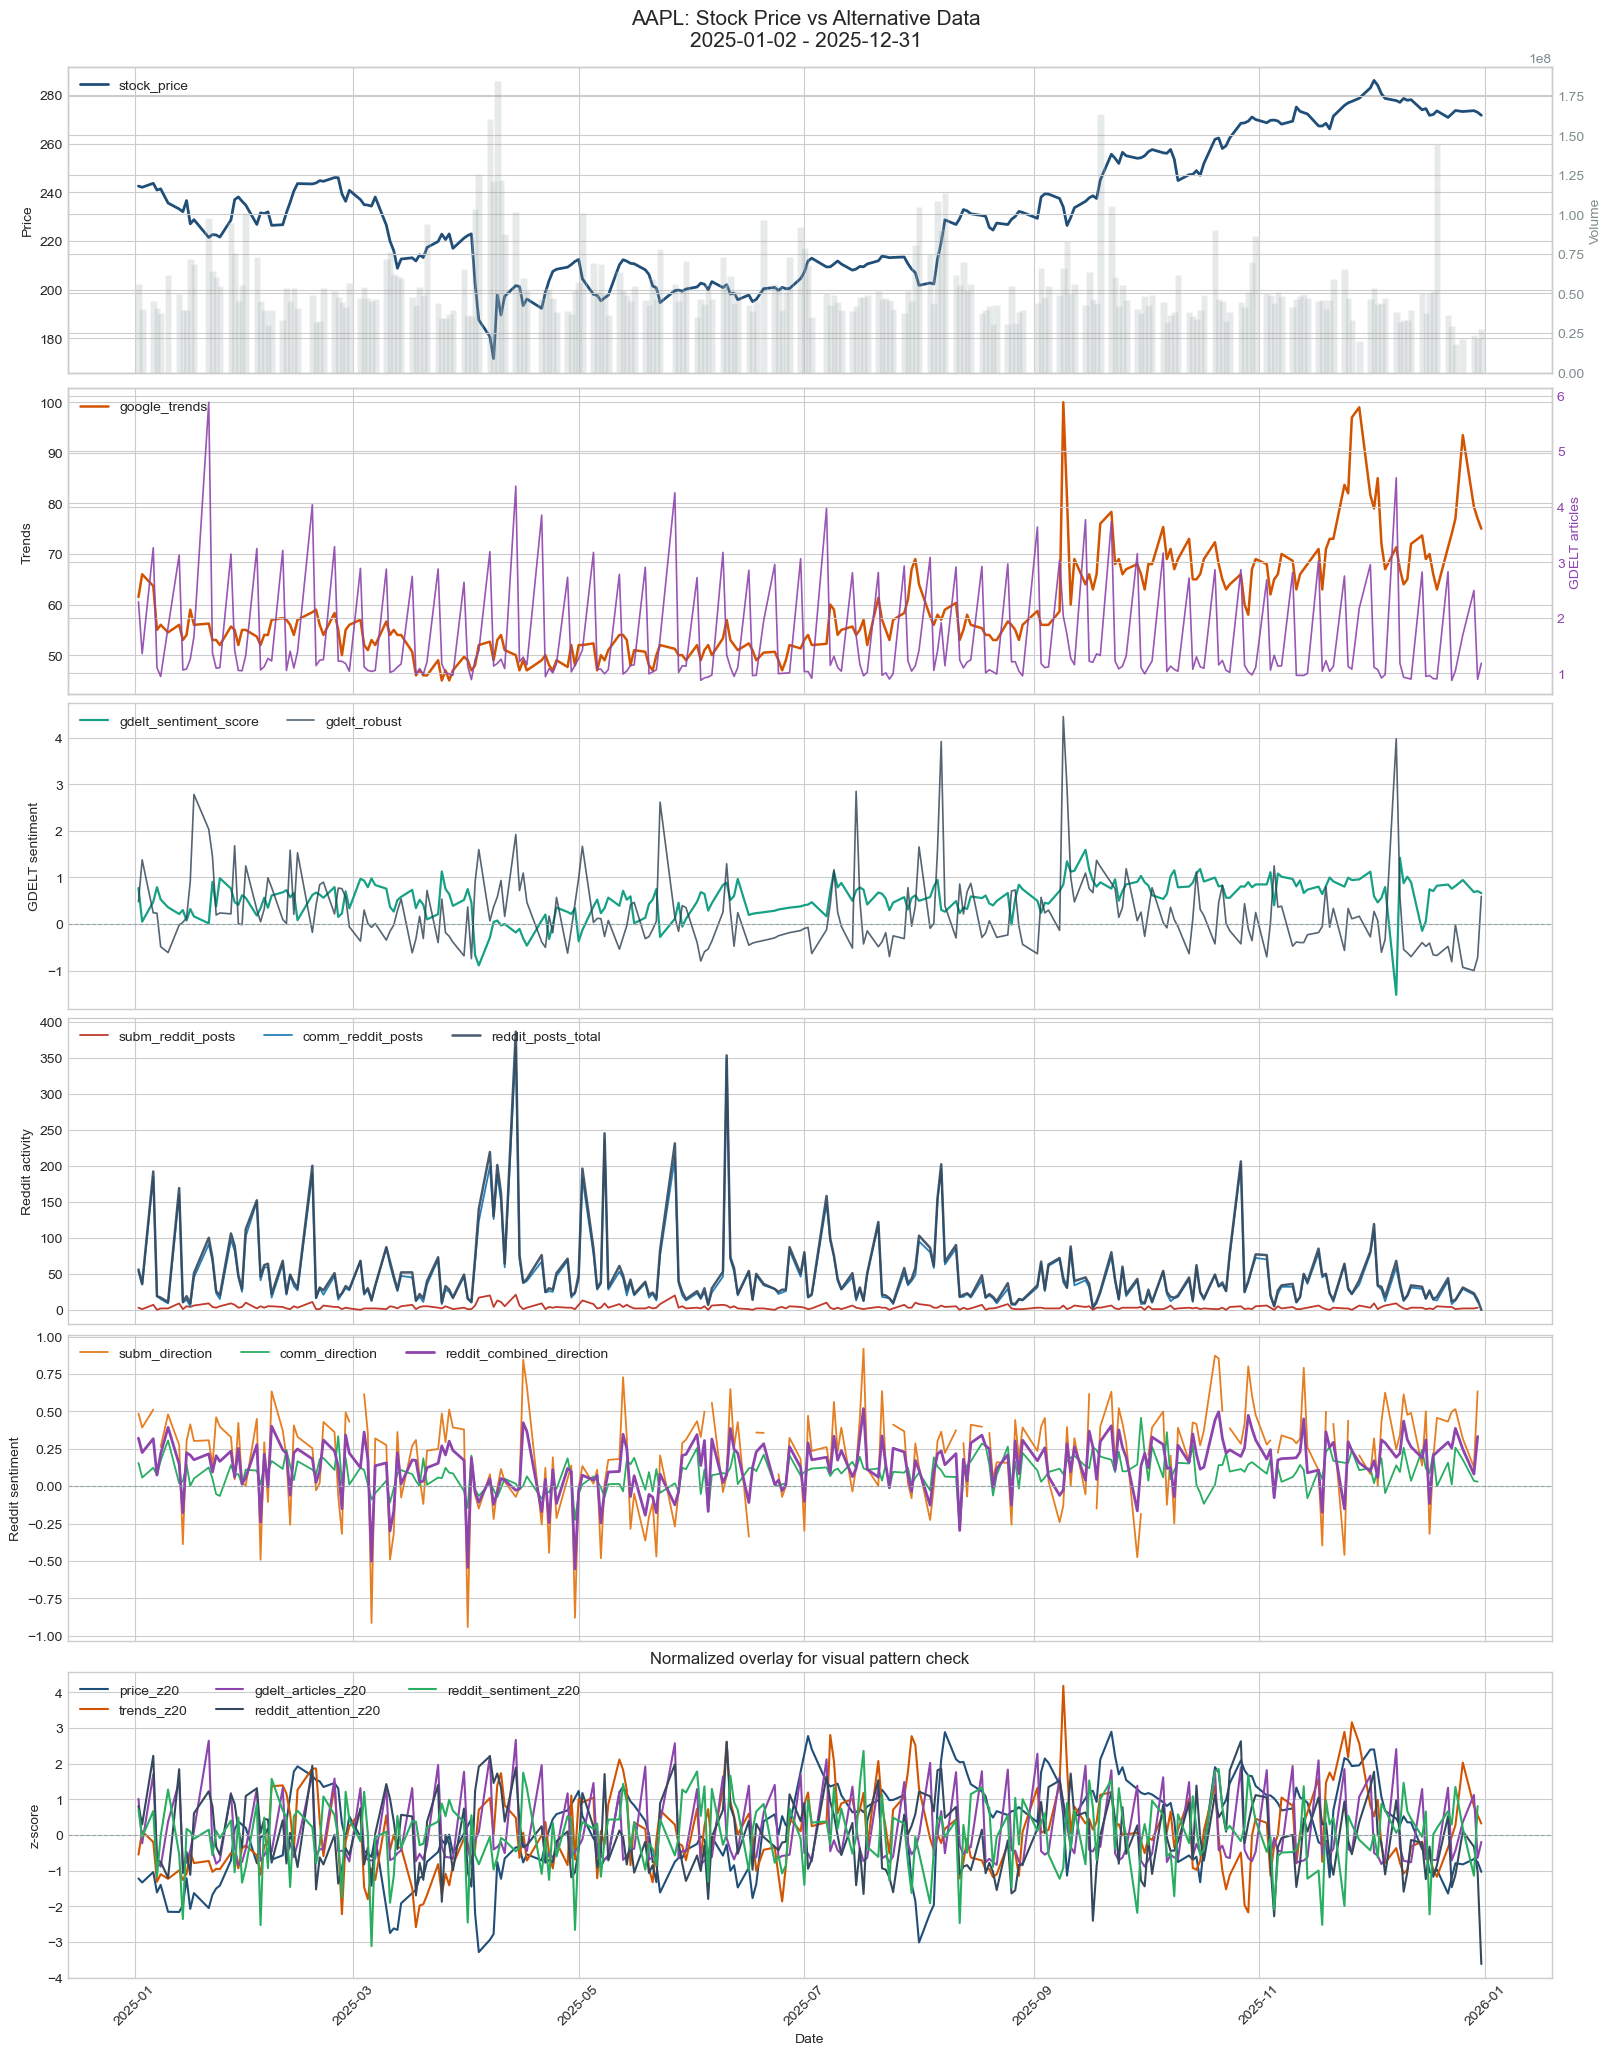

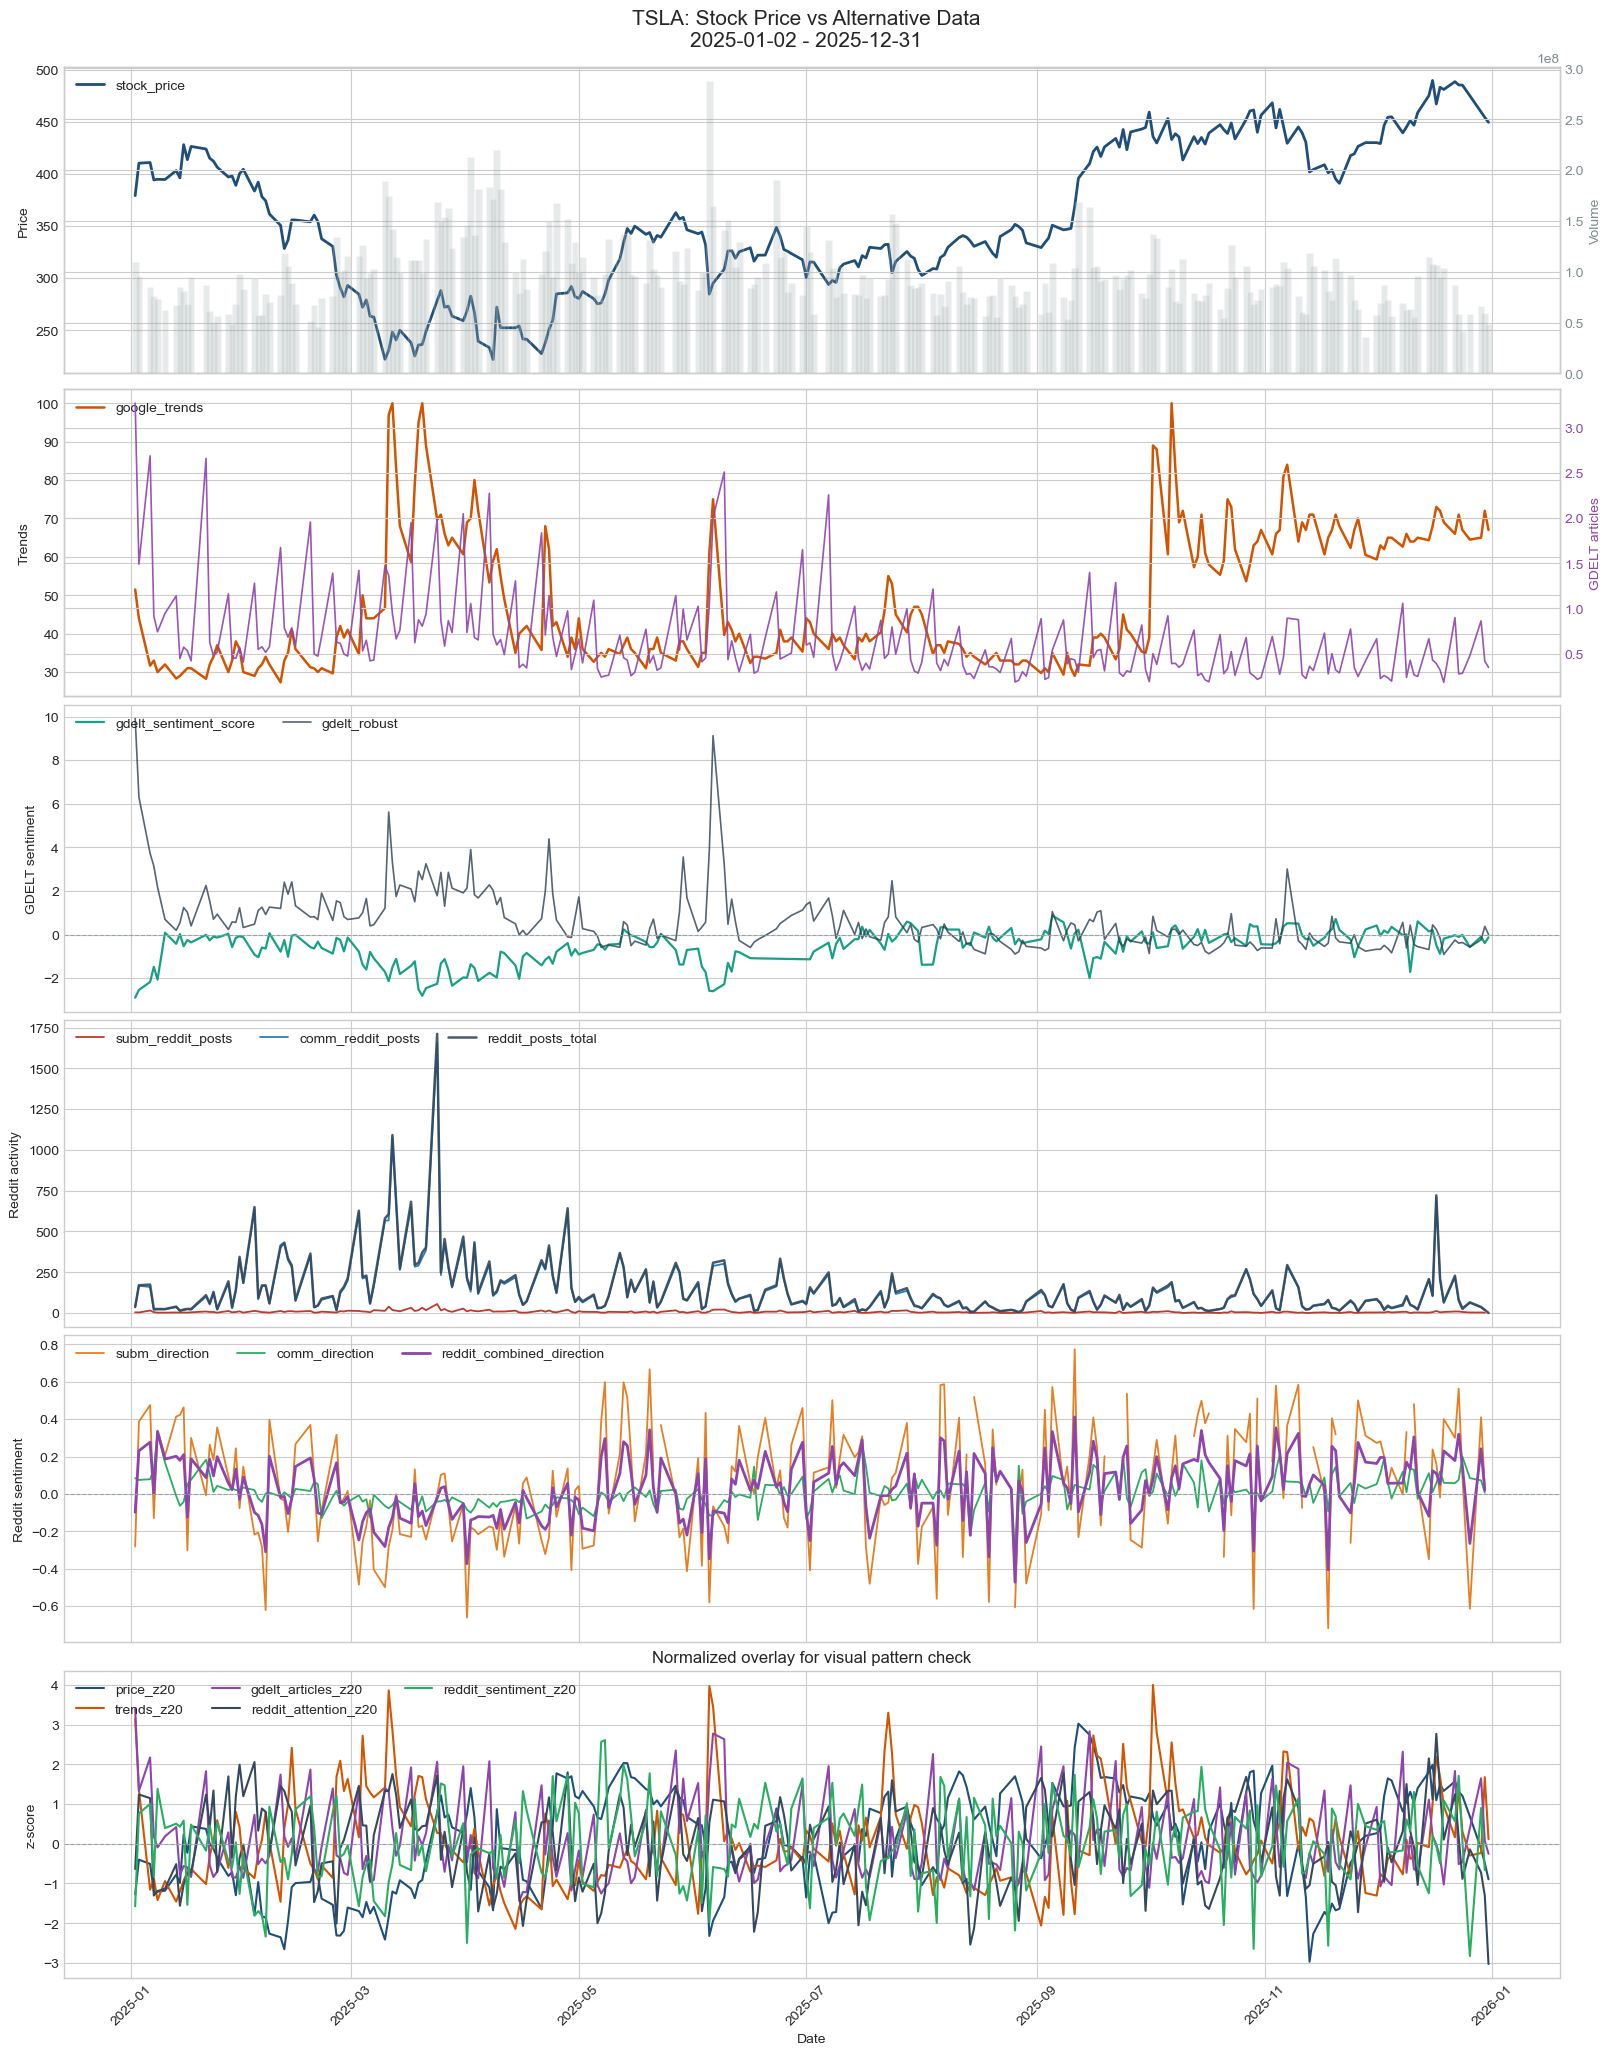

In [17]:
# Zmien ticker na "TSLA" albo inny z nowego panelu.
for ticker_name in ["AAPL", "TSLA"]:
    plot_ticker_dashboard(panel, ticker=ticker_name, start="2025-01-01", end="2025-12-31");


In [18]:
# Opcjonalny zapis PNG do outputs/visualizations
# save_dashboard(panel, ticker=ticker, start=start, end=end)
